# 02 - Baseline Forecasting Models

Before reaching for SARIMA, Prophet, or an ML model, we establish simple benchmark
forecasts. Any "real" model we build later has to beat these to justify its added
complexity -- this is standard practice (Hyndman & Athanasopoulos, *Forecasting:
Principles and Practice*).

Target: **statewide weekly total sales** (the sum across all category groups).

This notebook:
1. Rebuilds the statewide weekly series from the aggregated data
2. Creates a time-based train/test split (no shuffling -- this is a time series)
3. Implements three classical baselines: Naive, Seasonal Naive, Drift
4. Evaluates each on the held-out test period with MAPE, RMSE, and MAE
5. Visualizes forecasts against actuals

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/weekly_sales_by_category.csv", parse_dates=["week_start"])

statewide = df.groupby("week_start")["total_sales_dollars"].sum().reset_index()
statewide.columns = ["week_start", "total_sales"]
statewide = statewide.sort_values("week_start").reset_index(drop=True)

print("Total weeks:", len(statewide))
print("Range:", statewide["week_start"].min().date(), "to", statewide["week_start"].max().date())
statewide.head()

Total weeks: 487
Range: 2017-01-02 to 2026-04-27


,week_start,total_sales
0,2017-01-02,3844692.44
1,2017-01-09,4841547.61
2,2017-01-16,4519706.03
3,2017-01-23,4763505.57
4,2017-01-30,5120235.60


## Train/test split

We hold out the **last 52 weeks (one full year)** as the test set. This is a deliberate
choice, not an arbitrary one:

- It's a strict time-based split -- the model never sees the future during "training"
  (there's nothing to train for these baselines, but the same split will be reused for
  SARIMA/Prophet/ML, where this matters a lot).
- 52 weeks spans a full seasonal cycle, so seasonal methods can be judged fairly across
  every month, not just a partial year.
- It leaves 435 weeks (~8.4 years) of history, still plenty for seasonal-naive and any
  seasonal model to reference.
- It happens to hold out most of 2025 -- the first year with a year-over-year sales
  decline (see notebook 01). That's a feature, not a bug: it's a genuinely harder,
  more realistic test of whether a model naively assumes growth continues.

In [3]:
TEST_WEEKS = 52

train = statewide.iloc[:-TEST_WEEKS].copy()
test = statewide.iloc[-TEST_WEEKS:].copy()

print(f"Train: {len(train)} weeks, {train['week_start'].min().date()} to {train['week_start'].max().date()}")
print(f"Test:  {len(test)} weeks, {test['week_start'].min().date()} to {test['week_start'].max().date()}")

y_train = train["total_sales"].values
y_test = test["total_sales"].values
full_series = statewide["total_sales"].values
n_train = len(y_train)
h = len(y_test)

Train: 435 weeks, 2017-01-02 to 2025-04-28
Test:  52 weeks, 2025-05-05 to 2026-04-27


## Baseline methods

All three forecast the **entire 52-week horizon at once** from information available
only at the end of the training period (no peeking at test actuals as we go) -- this is
the harder, more honest evaluation and the one that matches how we'd actually deploy a
forecast.

- **Naive**: repeat the last observed training value for every future week.
- **Seasonal Naive**: for each future week, use the actual value from 52 weeks earlier.
  This is usually the toughest baseline to beat for series with strong yearly seasonality.
- **Drift**: extrapolate the straight line from the first to the last training
  observation forward. Captures a trend the flat naive method misses -- but assumes
  that trend continues indefinitely.

In [4]:
# Naive: last training value repeated
naive_fc = np.repeat(y_train[-1], h)

# Seasonal naive: value from 52 weeks before each test point
seasonal_naive_fc = np.array([full_series[n_train + i - 52] for i in range(h)])

# Drift: linear extrapolation from first to last training point
T = n_train
slope = (y_train[-1] - y_train[0]) / (T - 1)
drift_fc = np.array([y_train[-1] + slope * (i + 1) for i in range(h)])

forecasts = {
    "Naive": naive_fc,
    "Seasonal Naive": seasonal_naive_fc,
    "Drift": drift_fc,
}

print("Naive first 3 forecasts:", naive_fc[:3])
print("Seasonal Naive first 3 forecasts:", seasonal_naive_fc[:3])
print("Drift first 3 forecasts:", drift_fc[:3])

Naive first 3 forecasts: [7977247.94 7977247.94 7977247.94]
Seasonal Naive first 3 forecasts: [8400369.82 8582664.02 8314568.41]
Drift first 3 forecasts: [7986769.95728111 7996291.97456221 8005813.99184332]


## Evaluation

Three metrics, each telling a slightly different story:

- **MAPE** (Mean Absolute Percentage Error): scale-free, easy to communicate to
  stakeholders ("forecasts are off by X% on average"). Our primary metric.
- **RMSE**: in dollars, penalizes large misses more heavily -- relevant since we care
  about avoiding badly-wrong weeks (e.g. under-forecasting a spike week like the
  October pattern from notebook 01).
- **MAE**: in dollars, a more robust/less spike-sensitive companion to RMSE.

In [5]:
def mape(actual, pred):
    return np.mean(np.abs((actual - pred) / actual)) * 100

def rmse(actual, pred):
    return np.sqrt(np.mean((actual - pred) ** 2))

def mae(actual, pred):
    return np.mean(np.abs(actual - pred))

rows = []
for name, fc in forecasts.items():
    rows.append({
        "Model": name,
        "MAPE (%)": round(mape(y_test, fc), 2),
        "RMSE (USD)": round(rmse(y_test, fc)),
        "MAE (USD)": round(mae(y_test, fc)),
    })

results_df = pd.DataFrame(rows).set_index("Model").sort_values("MAPE (%)")
results_df

,MAPE (%),RMSE (USD),MAE (USD)
Model,,,
Seasonal Naive,8.29,853805,638806
Naive,8.44,893160,667219
Drift,9.73,971342,746185


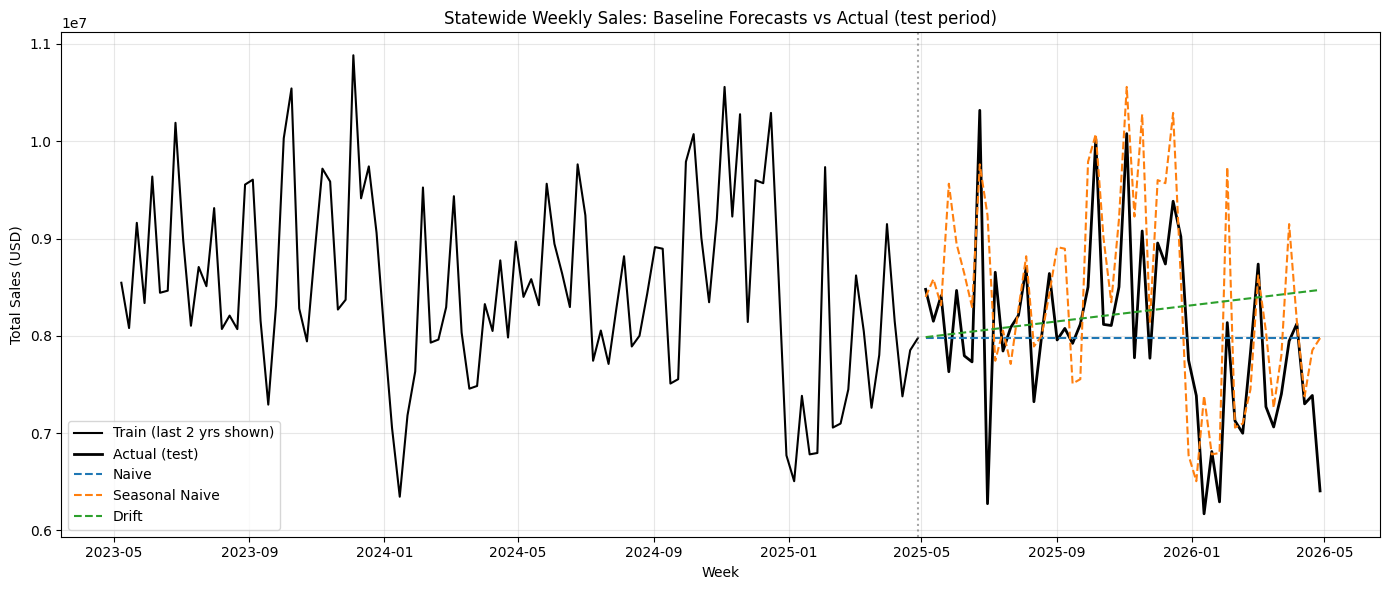

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(train["week_start"].iloc[-104:], y_train[-104:], label="Train (last 2 yrs shown)", color="black")
ax.plot(test["week_start"], y_test, label="Actual (test)", color="black", linewidth=2)
ax.plot(test["week_start"], naive_fc, label="Naive", linestyle="--")
ax.plot(test["week_start"], seasonal_naive_fc, label="Seasonal Naive", linestyle="--")
ax.plot(test["week_start"], drift_fc, label="Drift", linestyle="--")

ax.axvline(train["week_start"].iloc[-1], color="gray", linestyle=":", alpha=0.7)
ax.set_title("Statewide Weekly Sales: Baseline Forecasts vs Actual (test period)")
ax.set_xlabel("Week")
ax.set_ylabel("Total Sales (USD)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

**Results on the 52-week holdout (2025-05-05 to 2026-04-27):**

| Model | MAPE (%) | RMSE (USD) | MAE (USD) |
|---|---|---|---|
| Seasonal Naive | 8.29 | 853,805 | 638,806 |
| Naive | 8.44 | 893,160 | 667,219 |
| Drift | 9.73 | 971,342 | 746,185 |

Takeaways:

1. **Seasonal Naive is the benchmark to beat.** It edges out plain Naive, confirming
   there's real, exploitable yearly seasonality in this series -- but the margin over
   plain Naive is modest, meaning a strong model needs to do more than just repeat last
   year's shape to earn its complexity. The forecast plot shows why: Seasonal Naive
   matches the *timing* of the swings but not always the *magnitude*.
2. **Drift is the worst baseline**, and this is diagnostic, not just a data point: it
   extrapolates the 2017-2025 growth trend forward, but 2025 was the first
   year-over-year *decline* in the series (notebook 01, decision #6). The plot makes
   this visible -- Drift's rising line sits above most of the actual data in the back
   half of the test period. Any model we build next (SARIMA/Prophet/ML) needs to be able
   to represent a flattening or reversing trend, not just extrapolate historical growth.
3. **~8.3% MAPE is now the number to beat.** SARIMA, Prophet, and an ML approach are
   only worth shipping if they meaningfully beat Seasonal Naive on this same holdout,
   with the same metrics.

**Next steps:** SARIMA (with explicit yearly seasonal terms), Prophet (with holiday
effects), and a feature-based ML model (lag features + calendar features), each
evaluated on this identical 52-week holdout for a fair comparison.